# AI USAGE ASSIGNMENT
## Part A: Basic EDA(1-8)

In [2]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


### 1.Load the dataset and display the first 5 rows

In [3]:
#load dataset
df =  pd.read_csv('ai_assistant_usage_student_life.csv')
df.head()# displayng the first 5 rows of the dataset

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
0,SESSION00001,Undergraduate,Computer Science,2024-11-03,31.20,11,Studying,2,Assignment Completed,True,1.0
1,SESSION00002,Undergraduate,Psychology,2024-08-25,13.09,6,Studying,3,Assignment Completed,True,2.0
2,SESSION00003,Undergraduate,Business,2025-01-12,19.22,5,Coding,3,Assignment Completed,True,3.3
3,SESSION00004,Undergraduate,Computer Science,2025-05-06,3.70,1,Coding,3,Assignment Completed,True,3.5
4,SESSION00005,Undergraduate,Psychology,2025-03-18,28.12,9,Writing,3,Assignment Completed,True,2.9


### 2.Check the dataset shape (rows, columns).

In [4]:
#check dataset shape (rows, columns)
print(df.shape)

(10000, 11)


### 3.Display column names and their data types.


In [5]:
#check column names and their data types(summary)
print(df.columns)
print(df.info())

Index(['SessionID', 'StudentLevel', 'Discipline', 'SessionDate',
       'SessionLengthMin', 'TotalPrompts', 'TaskType', 'AI_AssistanceLevel',
       'FinalOutcome', 'UsedAgain', 'SatisfactionRating'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SessionID           10000 non-null  object 
 1   StudentLevel        10000 non-null  object 
 2   Discipline          10000 non-null  object 
 3   SessionDate         10000 non-null  object 
 4   SessionLengthMin    10000 non-null  float64
 5   TotalPrompts        10000 non-null  int64  
 6   TaskType            10000 non-null  object 
 7   AI_AssistanceLevel  10000 non-null  int64  
 8   FinalOutcome        10000 non-null  object 
 9   UsedAgain           10000 non-null  bool   
 10  SatisfactionRating  10000 non-null  float64
dtypes: bool(1), float64(2), int

### 4.Check for missing values in each column.
 

In [6]:
#checking missing values
df.isnull().sum()

SessionID             0
StudentLevel          0
Discipline            0
SessionDate           0
SessionLengthMin      0
TotalPrompts          0
TaskType              0
AI_AssistanceLevel    0
FinalOutcome          0
UsedAgain             0
SatisfactionRating    0
dtype: int64

- there are no missing values in the dataset.

### 5.Show summary statistics for SessionLengthMin and TotalPrompts.

In [7]:
#summary statistics for SessionLengthMin and TotalPrompts
print(df[['SessionLengthMin','TotalPrompts']].describe())

       SessionLengthMin  TotalPrompts
count      10000.000000  10000.000000
mean          19.846467      5.607500
std           13.897302      4.648764
min            0.030000      1.000000
25%            9.630000      2.000000
50%           16.650000      4.000000
75%           26.670000      8.000000
max          110.810000     39.000000


### 6.Find the number of unique values in StudentLevel, Discipline, and TaskType.

In [8]:
#find unique values in studentlevel,discipline and tasktype
print(df['StudentLevel'].unique())
print(df['Discipline'].unique())
print(df['TaskType'].unique())


['Undergraduate' 'Graduate' 'High School']
['Computer Science' 'Psychology' 'Business' 'Biology' 'Math' 'History'
 'Engineering']
['Studying' 'Coding' 'Writing' 'Brainstorming' 'Homework Help' 'Research']


### 7.Which TaskType is the most common?

In [9]:
#which tasktype is common
common_task=df['TaskType'].value_counts()
print(common_task)

TaskType
Writing          3101
Studying         2040
Homework Help    1959
Coding           1948
Brainstorming     476
Research          476
Name: count, dtype: int64


- the common task was writing .
- you can put idxmax() at the end to list the task with most id assigned to it.

### 8.Calculate the average SessionLengthMin for each StudentLevel.

In [10]:
#average sessionlengthmin for each studentlevel
avg_session_by_level=df.groupby('StudentLevel')['SessionLengthMin'].mean()
print(avg_session_by_level)

StudentLevel
Graduate         20.252236
High School      20.023740
Undergraduate    19.650943
Name: SessionLengthMin, dtype: float64


## Part B: VISUALIZATION(9-16)
### 9.Plot a histogram of SessionLengthMin.

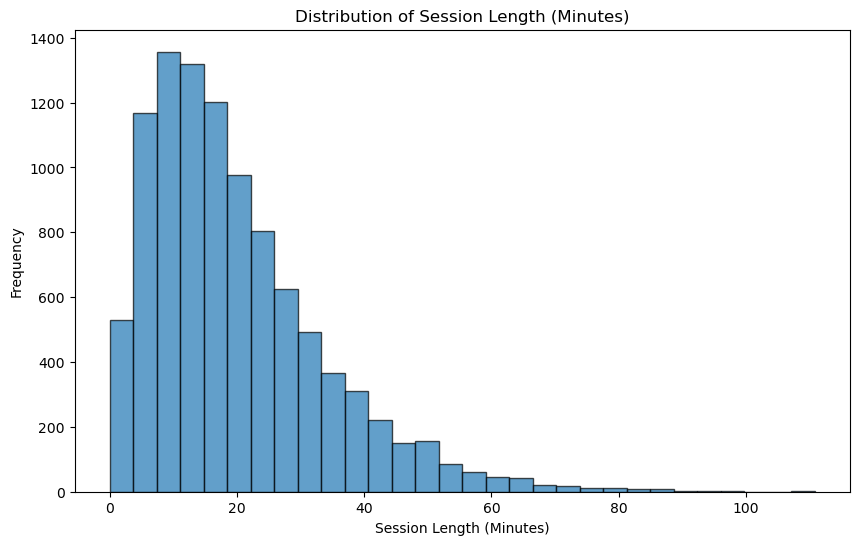

In [11]:
#plot histogramn of SessionLengthMin
plt.figure(figsize=(10,6))
plt.hist(df['SessionLengthMin'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Session Length (Minutes)')
plt.xlabel('Session Length (Minutes)')
plt.ylabel('Frequency')
plt.show()

### 10.Create a bar chart of session counts by StudentLevel.


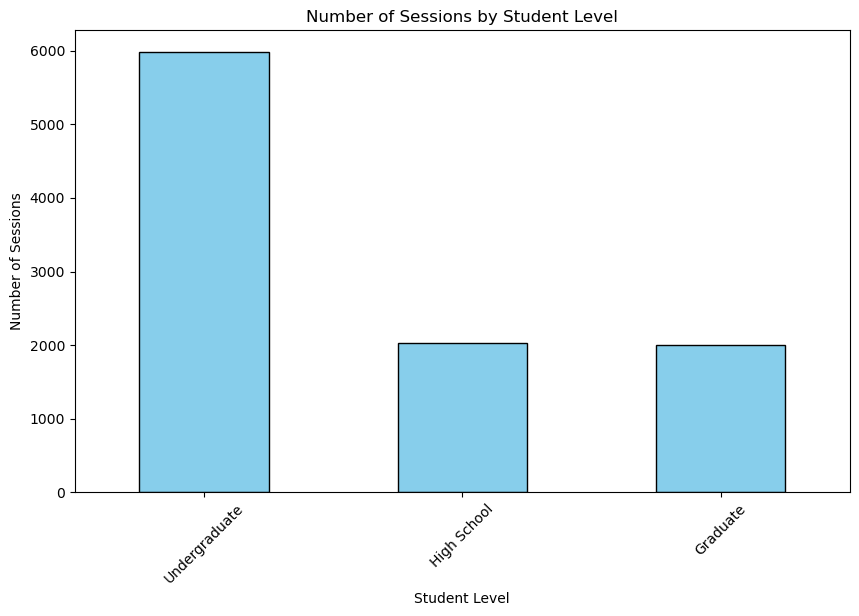

In [12]:
#create barchart of Session Counts by StudentLevel
plt.figure(figsize=(10, 6))
df['StudentLevel'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Sessions by Student Level')
plt.xlabel('Student Level')
plt.ylabel('Number of Sessions')
plt.xticks(rotation=45)
plt.show()

### 11.Make a countplot of TaskType using Seaborn.

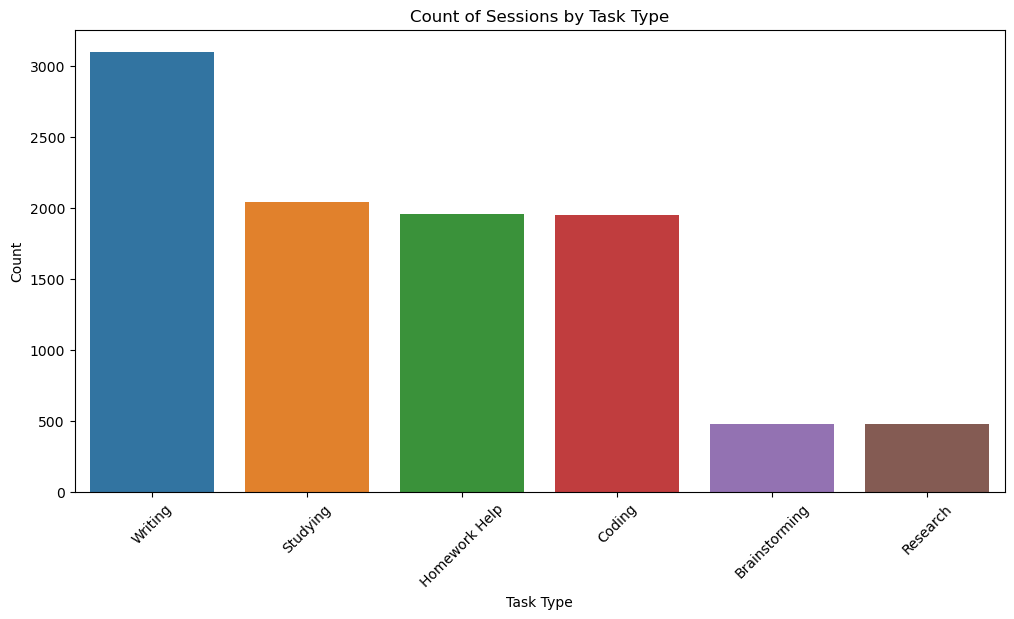

In [13]:
#make a countplot of TaskType using Seaborn
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='TaskType', order=df['TaskType'].value_counts().index)
plt.title('Count of Sessions by Task Type')
plt.xlabel('Task Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### 12.Plot a boxplot of SessionLengthMin grouped by StudentLevel.

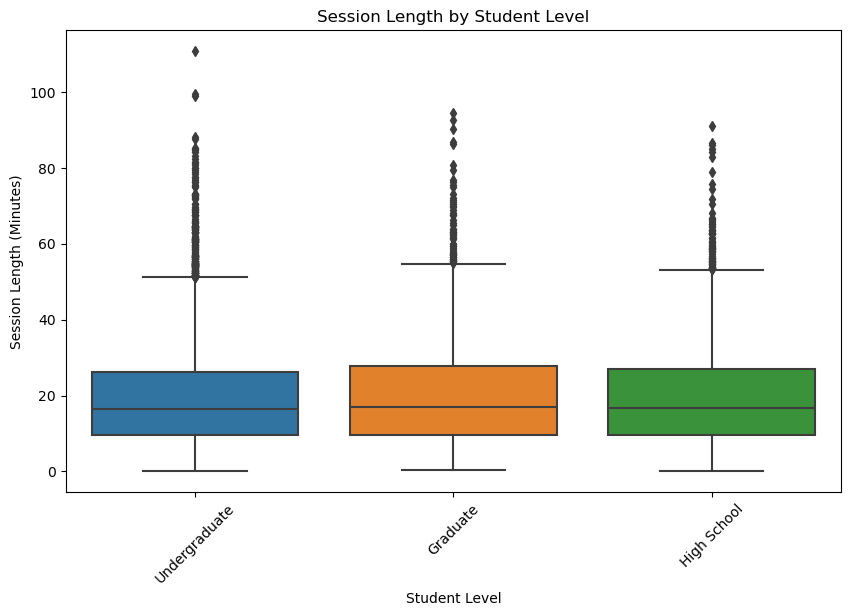

In [14]:
# Plot a boxplot of SessionLengthMin grouped by StudentLevel
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='StudentLevel', y='SessionLengthMin')
plt.title('Session Length by Student Level')
plt.xlabel('Student Level')
plt.ylabel('Session Length (Minutes)')
plt.xticks(rotation=45)
plt.show()


### 13.Create a pie chart showing proportions of FinalOutcome.

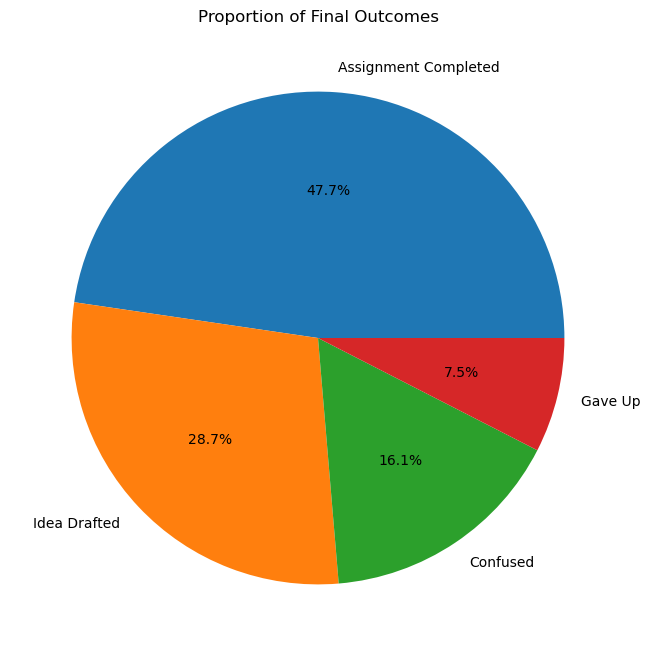

In [15]:
# Create a pie chart showing proportions of FinalOutcome
plt.figure(figsize=(8, 8))
df['FinalOutcome'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Proportion of Final Outcomes')
plt.ylabel('')
plt.show()

### 14.Draw a scatterplot of SessionLengthMin vs. TotalPrompts.


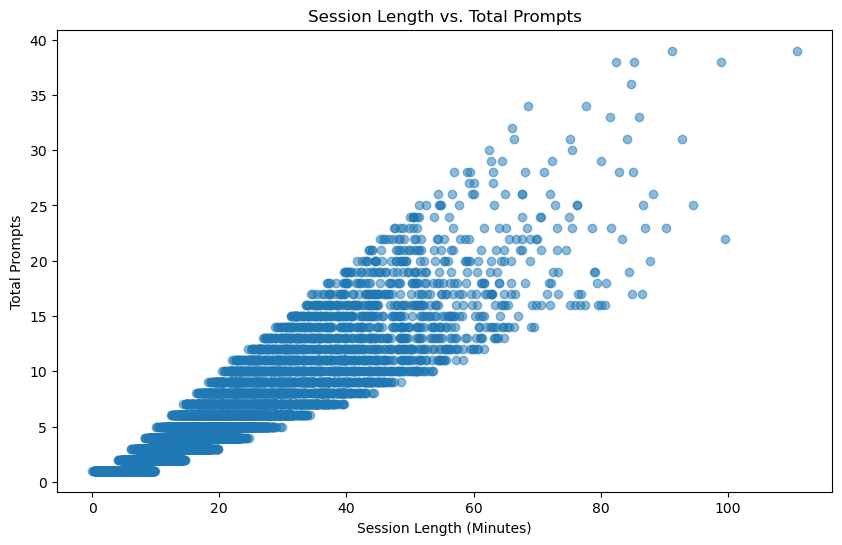

In [16]:
# Draw a scatterplot of SessionLengthMin vs. TotalPrompts
plt.figure(figsize=(10, 6))
plt.scatter(df['SessionLengthMin'], df['TotalPrompts'], alpha=0.5)
plt.title('Session Length vs. Total Prompts')
plt.xlabel('Session Length (Minutes)')
plt.ylabel('Total Prompts')
plt.show()

In [17]:
# Convert SessionDate to datetime for time-based analysis
df['SessionDate'] = pd.to_datetime(df['SessionDate'])

### 15.Plot a line chart of average AI_AssistanceLevel over time (SessionDate).

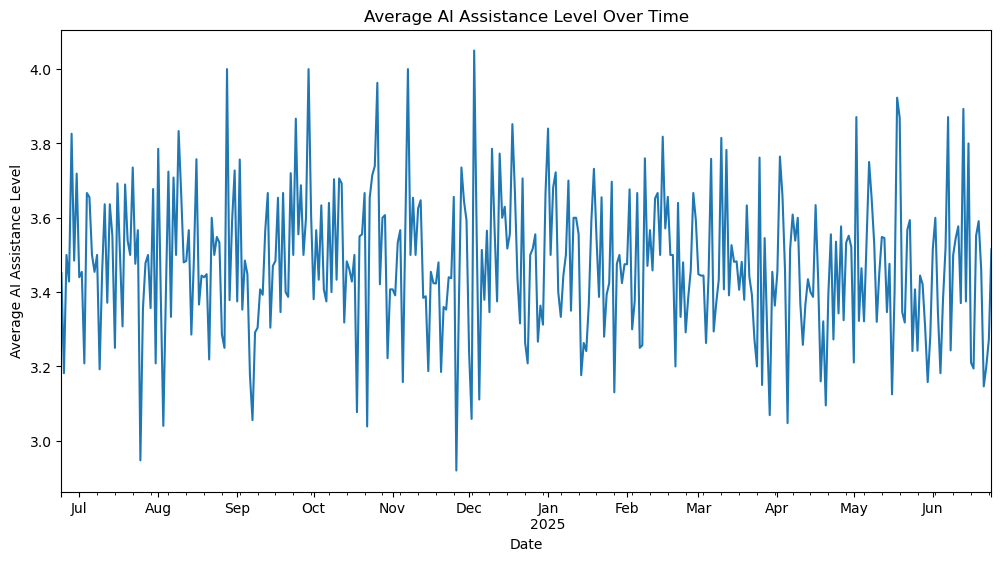

In [18]:
# Plot a line chart of average AI_AssistanceLevel over time (SessionDate)
plt.figure(figsize=(12, 6))
df.groupby('SessionDate')['AI_AssistanceLevel'].mean().plot()
plt.title('Average AI Assistance Level Over Time')
plt.xlabel('Date')
plt.ylabel('Average AI Assistance Level')
plt.show()

### 16.Create a heatmap of correlations among numeric features.

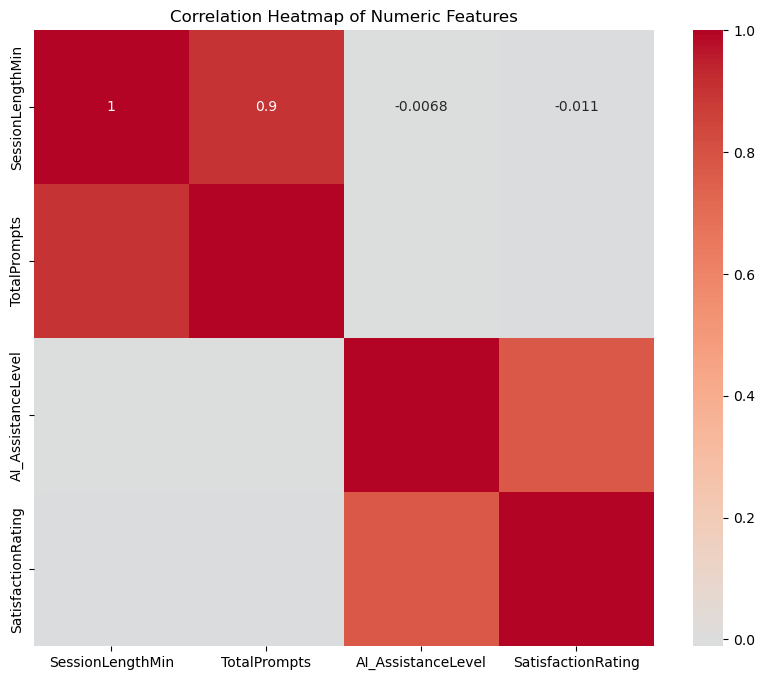

In [19]:
# Create a heatmap of correlations among numeric features
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

## Part C: GROUPBY & AGGREGATIONS(17-21)

### 17.Find the average SessionLengthMin for each TaskType.

In [20]:
# calculating average sessionlengthmin for each tasktype
avg_session_by_task=df.groupby('TaskType')['SessionLengthMin'].mean()
print(avg_session_by_task)

TaskType
Brainstorming    21.964223
Coding           19.467659
Homework Help    19.940536
Research         20.410000
Studying         19.705917
Writing          19.705888
Name: SessionLengthMin, dtype: float64


### 18.Which Discipline had the most sessions?

In [21]:
#which discipline had the most sessions?
discipline_high=df["Discipline"].value_counts()
print(discipline_high)

Discipline
Biology             1458
Computer Science    1445
Engineering         1430
Math                1422
Psychology          1418
History             1417
Business            1410
Name: count, dtype: int64


- discipline with the highest sessions is Biology with 1458 sessions.

### 19.Compare average AI_AssistanceLevel across StudentLevel

In [22]:
avg_ai_by_level = df.groupby('StudentLevel')['AI_AssistanceLevel'].mean()
print(avg_ai_by_level)

StudentLevel
Graduate         3.469674
High School      3.477060
Undergraduate    3.483607
Name: AI_AssistanceLevel, dtype: float64


### 20.Find the most common FinalOutcome for Graduate students.


In [23]:
#find the most common finaloutcome  for graduate students
grad_df = df[df['StudentLevel']=='Graduate']
most_outcome_grad = grad_df['FinalOutcome'].value_counts()
print(most_outcome_grad)

FinalOutcome
Assignment Completed    936
Idea Drafted            567
Confused                331
Gave Up                 161
Name: count, dtype: int64


### 21.Calculate the median SessionLengthMin for each FinalOutcome.

In [24]:
#calculate median sessionlengthmin for finaloutcome
median_session_outcome = df.groupby('FinalOutcome')['SessionLengthMin'].median()
print(median_session_outcome)

FinalOutcome
Assignment Completed    16.570
Confused                16.040
Gave Up                 17.290
Idea Drafted            17.085
Name: SessionLengthMin, dtype: float64


## Part D:FEATURE ENGINEERING AND ENCODING(22-26)
### 22.Convert SessionDate into Year, Month, and Day columns.

In [25]:
#convert sessiondate into year, month, and day columns
df['Year'] = df['SessionDate'].dt.year
df['Month'] = df['SessionDate'].dt.month
df['Day'] = df['SessionDate'].dt.day

print("Dataset with new date columns")# heading for the dataset
print(df[['SessionDate','Year','Month','Day']].head())

Dataset with new date columns
  SessionDate  Year  Month  Day
0  2024-11-03  2024     11    3
1  2024-08-25  2024      8   25
2  2025-01-12  2025      1   12
3  2025-05-06  2025      5    6
4  2025-03-18  2025      3   18


### 23.Encode StudentLevel using Label Encoding.

In [26]:
#label encoding used to convert categorical data into a numerical format suitable for machine learning models. 
#encode StudentLevel using label encoding
le = LabelEncoder()
df['StudentLevel_Encoded'] = le.fit_transform(df['StudentLevel'])
print(df[['StudentLevel','StudentLevel_Encoded']].head(10))

    StudentLevel  StudentLevel_Encoded
0  Undergraduate                     2
1  Undergraduate                     2
2  Undergraduate                     2
3  Undergraduate                     2
4  Undergraduate                     2
5       Graduate                     0
6    High School                     1
7  Undergraduate                     2
8  Undergraduate                     2
9  Undergraduate                     2


### 24.Apply One-Hot Encoding to TaskType.

In [27]:
#to give zero and ones instead of false and true
df_encoded = pd.get_dummies(df['TaskType'],drop_first=True)
df_encoded= df_encoded.astype(int)
print(df_encoded.head())

   Coding  Homework Help  Research  Studying  Writing
0       0              0         0         1        0
1       0              0         0         1        0
2       1              0         0         0        0
3       1              0         0         0        0
4       0              0         0         0        1


- alternative if you want false or true instead of one or zeros

In [28]:
#apply one-hot encoding to tasktype
from encodings.uu_codec import uu_encode

task_type_dummies = pd.get_dummies(df['TaskType'],prefix='Task')
df = pd.concat([df,task_type_dummies],axis = 1)
print(df.filter(like = 'Task').head())


   TaskType  Task_Brainstorming  Task_Coding  Task_Homework Help  \
0  Studying               False        False               False   
1  Studying               False        False               False   
2    Coding               False         True               False   
3    Coding               False         True               False   
4   Writing               False        False               False   

   Task_Research  Task_Studying  Task_Writing  
0          False           True         False  
1          False           True         False  
2          False          False         False  
3          False          False         False  
4          False          False          True  


- One Hot Encoding is a method for converting categorical variables into a binary format. It creates new columns for each category where 1 means the category is present and 0 means it is not. The primary purpose of One Hot Encoding is to ensure that categorical data can be effectively used in machine learning models.

### 25.Create a new feature: PromptsPerMinute = TotalPrompts / SessionLengthMin.


In [29]:
#create a  new feature :promptsperminute = totalprompts/sessionlengthmin
df['PromptsPerMinute'] = df['TotalPrompts']/df['SessionLengthMin']
print(df[['TotalPrompts','SessionLengthMin','PromptsPerMinute']].head())

   TotalPrompts  SessionLengthMin  PromptsPerMinute
0            11             31.20          0.352564
1             6             13.09          0.458365
2             5             19.22          0.260146
3             1              3.70          0.270270
4             9             28.12          0.320057


### 26.Bin SessionLengthMin into categories: Short, Medium, Long.

In [30]:
#bin sessionlengthmin into categories:Short , Medium, Long
bins = [0,10,30,df['SessionLengthMin'].max()]
labels = ['Short','Medium','Long']
df['SessionLengthCategory'] = pd.cut(df['SessionLengthMin'],bins = bins, labels=labels)
print(df['SessionLengthCategory'].value_counts())

SessionLengthCategory
Medium    5401
Short     2643
Long      1956
Name: count, dtype: int64


## Part E: Machine Learning (Classification Models)(27-36)

In [46]:
#importing necessary libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score,recall_score,confusion_matrix, classification_report
import xgboost as xgb



In [32]:
# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [36]:
# Convert categorical variables to numerical(ENCODING)
le = LabelEncoder()
df['StudentLevel_encoded'] = le.fit_transform(df['StudentLevel'])
df['Discipline_Encoded'] = le.fit_transform(df['Discipline'])
df['TaskType_Encoded'] = le.fit_transform(df['TaskType'])
df['FinalOutcome_encoded'] = le.fit_transform(df['FinalOutcome'])
df['UsedAgain_encoded'] = le.fit_transform(df['UsedAgain'])

In [38]:
# Select features for models
features = ['StudentLevel_encoded', 'Discipline_Encoded', 'SessionLengthMin', 
            'TotalPrompts', 'TaskType_Encoded', 'AI_AssistanceLevel', 'SatisfactionRating']

#split features and targets
X = df[features]
y_outcome = df['FinalOutcome_encoded']


### 34.Split the dataset into 80% training and 20% testing sets.

In [40]:
X_train, X_test, y_outcome_train, y_outcome_test = train_test_split(X, y_outcome, test_size=0.2, random_state=42)




In [41]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
print("Data preparation complete. Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Data preparation complete. Training set shape: (8000, 7)
Testing set shape: (2000, 7)


### 27.Predict FinalOutcome using a Decision Tree Classifier.

In [43]:
# 1. Predict FinalOutcome using a Decision Tree Classifier
dt_outcome = DecisionTreeClassifier(random_state=42)
dt_outcome.fit(X_train, y_outcome_train)
y_pred_dt_outcome = dt_outcome.predict(X_test)
accuracy_dt_outcome = accuracy_score(y_outcome_test, y_pred_dt_outcome)
print(f"Decision Tree Accuracy for FinalOutcome: {accuracy_dt_outcome:.4f}")

Decision Tree Accuracy for FinalOutcome: 0.3530


In [ ]:
# 2. Evaluation(confusion marix)
print("Accuracy:", accuracy_score(y_outcome_test, y_pred_dt_outcome))
print("Precision (macro):", precision_score(y_outcome_test, y_pred_dt_outcome, average='macro'))
print("\nConfusion Matrix:\n", confusion_matrix(y_outcome_test, y_pred_dt_outcome))

#print("\nClassification Report:\n", classification_report(y_outcome_test, y_pred_dt_outcome, labels=labels, target_names=le.inverse_transform(labels)))
#print("\nDetailed Classification Report:\n", classification_report(y_outcome_test, y_pred_dt_outcome, target_names=le.classes_))

Accuracy: 0.353
Precision (macro): 0.26265919178465946

Confusion Matrix:
 [[469 157  66 238]
 [150  57  39 103]
 [ 72  37  14  47]
 [259  88  38 166]]


### 28.Predict UsedAgain using Logistic Regression.

In [ ]:
# Define features (same as before)
tasktype_features = [col for col in df.columns if col.startswith("TaskType_")]

features = [
    'SessionLengthMin',
    'TotalPrompts',
    'AI_AssistanceLevel',
    'PromptsPerMinute',
    'StudentLevel_encoded',
    'Discipline_encoded',
    'Year', 'Month', 'Day'
] + tasktype_features

X = df[features]
y = df["UsedAgain_encoded"]

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Train
log_reg.fit(X_train, y_train)

# Predict
y_pred_log = log_reg.predict(X_test)

In [ ]:
#logistic regression accuracy
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg.predict(X_test_scaled)
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"Logistic Regression Accuracy for UsedAgain: {accuracy_log_reg:.4f}")

Logistic Regression Accuracy for UsedAgain: 0.6925


In [ ]:
#Evaluate(Confusion matrix, classification report)
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision (macro):", precision_score(y_test, y_pred_log, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred_log, average='macro'))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nDetailed Classification Report:\n",classification_report(y_test, y_pred_log, target_names=[str(c) for c in log_reg.classes_]))

Accuracy: 0.6925
Precision (macro): 0.34625
Recall (macro): 0.5

Confusion Matrix:
 [[   0  615]
 [   0 1385]]

Detailed Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       615
           1       0.69      1.00      0.82      1385

    accuracy                           0.69      2000
   macro avg       0.35      0.50      0.41      2000
weighted avg       0.48      0.69      0.57      2000



c:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classifi

### 29.Train a Random Forest Classifier to predict FinalOutcome.

In [ ]:
model_rf= RandomForestClassifier(n_estimators=100,random_state=42)#initialize model
model_rf.fit(X_train,y_train)#train model
y_pred_rf=model_rf.predict(X_test)#predict model

accuracy_rf_outcome = accuracy_score(y_test,y_pred_rf)#test accuracy
print(f"Random Forest Accuracy for FinalOutcome: {accuracy_rf_outcome:.4f}")


Random Forest Accuracy for FinalOutcome: 0.6805


In [ ]:
# Evaluation(Accuracy, Precision, Confusion matrix)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision (macro):", precision_score(y_test, y_pred_rf, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred_rf, average='macro'))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

#labels = np.unique(y_test)  # only use labels present in y_test
#print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, labels=labels, target_names=le.inverse_transform(labels)))


Accuracy: 0.6805
Precision (macro): 0.5293600228223659
Recall (macro): 0.5057996536644067

Confusion Matrix:
 [[  32  583]
 [  56 1329]]


### 30.Use KNN (K-Nearest Neighbors) to classify UsedAgain.

In [ ]:
#initialize model
knn=KNeighborsClassifier(n_neighbors=5)#you can tune the n_neighbors 
knn.fit(X_train,y_train)#train model
y_pred_knn=knn.predict(X_test)#predict model
accuracy_score_knn=accuracy_score(y_test,y_pred_knn)#predict accuracy
print(f"KNN Accuracy score is:{accuracy_score_knn:.4f}")

KNN Accuracy score is:0.6335


In [ ]:
# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision (macro):", precision_score(y_test, y_pred_knn, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred_knn, average='macro'))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
#print("\nDetailed Classification Report:\n",classification_report(y_test, y_pred_knn, target_names=[str(c) for c in le_used.classes_]))

Accuracy: 0.6335
Precision (macro): 0.495995114833143
Recall (macro): 0.4976284816999794

Confusion Matrix:
 [[  89  526]
 [ 207 1178]]


### 31.Train a Naive Bayes Classifier to predict FinalOutcome.

In [ ]:
model_nb=GaussianNB()#initialize the model
model_nb.fit(X_train,y_train)#train the model
y_pred_nb = model_nb.predict(X_test)#predict the model
accuracy_score_nb=accuracy_score(y_test,y_pred_nb)#predict accuracy score
print(f"Naive Bayes accuracy is:{accuracy_score_nb:.4f}")

Naive Bayes accuracy is:0.6855


In [ ]:
#confusion matrix ,precision,accuracy scores
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision (macro):", precision_score(y_test, y_pred_nb, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred_nb, average='macro'))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))


Accuracy: 0.6855
Precision (macro): 0.42045454545454547
Recall (macro): 0.49630184027472046

Confusion Matrix:
 [[   3  612]
 [  17 1368]]


### 32.Build a Gradient Boosting Classifier for UsedAgain.

In [ ]:
gb_classifier= GradientBoostingClassifier(random_state=42)#initialize
gb_classifier.fit(X_train,y_train)#train model
y_pred_gb =gb_classifier.predict(X_test)#predict model
accuracy_score_gb=accuracy_score(y_test,y_pred_gb)#test model accuracy
print (f"Gradient Boosting Classifier :{accuracy_score_gb:.4f}")

Gradient Boosting Classifier :0.6905


In [72]:
#confusion matrix,precision , accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision (macro):", precision_score(y_test, y_pred_gb, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred_gb, average='macro'))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
#print("\nClassification Report:\n", classification_report(y_test, y_pred_gb, target_names=[str(c) for c in le_used.classes_]))

Accuracy: 0.6905
Precision (macro): 0.5249964033951949
Recall (macro): 0.5008159431774823

Confusion Matrix:
 [[   5  610]
 [   9 1376]]


### 33.Apply an XGBoost Classifier to predict FinalOutcome.

In [73]:
xgb=XGBClassifier(use_label_encoder=False,eval_metric='mlogloss',random_state=42)
xgb.fit(X_train,y_train)
y_pred_xgb=xgb.predict(X_test)
accuracy_score_xgb=accuracy_score(y_test,y_pred_xgb)
print(f"accuracy xgb score for finaloutcome is:{accuracy_score_xgb:.4f}")

c:\Users\admin\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:28:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


accuracy xgb score for finaloutcome is:0.6590


In [75]:
#confusion matrix, accuracy, precision
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision (macro):", precision_score(y_test, y_pred_xgb, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred_xgb, average='macro'))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
#print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb, target_names=le.classes_))

Accuracy: 0.659
Precision (macro): 0.5237905372838285
Recall (macro): 0.5110680637492295

Confusion Matrix:
 [[  78  537]
 [ 145 1240]]


### 35.Evaluate one model using accuracy and a confusion matrix.


Logistic Regression Evaluation for UsedAgain:
Accuracy: 0.6925


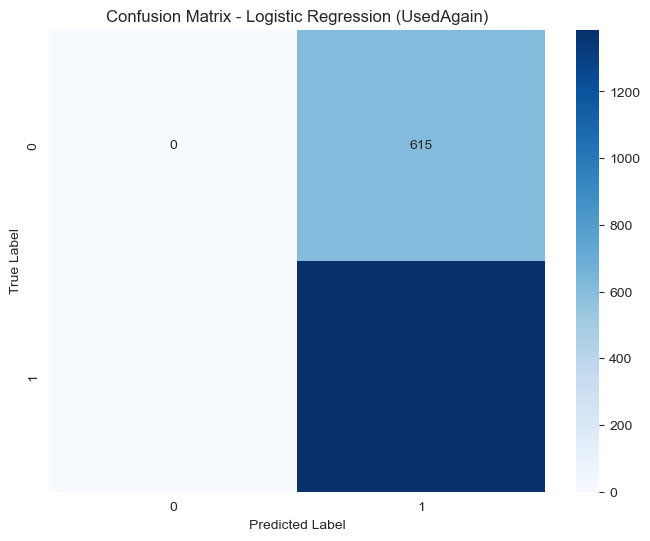

In [ ]:
#evaluate logistic regression model
print("\nLogistic Regression Evaluation for UsedAgain:")
print(f"Accuracy: {accuracy_log_reg:.4f}")

#confusion matrix plot
cm_lr = confusion_matrix(y_test,y_pred_log)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression (UsedAgain)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### 36.Generate a classification report (precision, recall, f1-score).

In [78]:
print("\nClassification Report for Logistic Regression (UsedAgain):")
print(classification_report(y_test, y_pred_log, 
                            target_names=['Not Used Again', 'Used Again']))


Classification Report for Logistic Regression (UsedAgain):
                precision    recall  f1-score   support

Not Used Again       0.00      0.00      0.00       615
    Used Again       0.69      1.00      0.82      1385

      accuracy                           0.69      2000
     macro avg       0.35      0.50      0.41      2000
  weighted avg       0.48      0.69      0.57      2000



c:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## Part F:Model Evaluation & Hyperparameter Tuning(37-40)
### 37.Perform cross-validation for Logistic Regression.

In [79]:
cv_scores_lr = cross_val_score(log_reg, X_train_scaled, y_train, cv=5)
print(f"Logistic Regression Cross-Validation Scores: {cv_scores_lr}")
print(f"Mean CV Accuracy: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std() * 2:.4f})")

Logistic Regression Cross-Validation Scores: [0.71     0.71     0.71     0.71     0.709375]
Mean CV Accuracy: 0.7099 (+/- 0.0005)


### 38.Use GridSearchCV to tune hyperparameters of a Decision Tree.

In [80]:
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt = DecisionTreeClassifier(random_state=42)
grid_search_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='accuracy')
grid_search_dt.fit(X_train, y_outcome_train)

print("\nBest parameters for Decision Tree:")
print(grid_search_dt.best_params_)
print(f"Best cross-validation score: {grid_search_dt.best_score_:.4f}")


Best parameters for Decision Tree:
{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation score: 0.4926


### 39.Tune a Random Forest Classifier (n_estimators, max_depth).


In [81]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train, y_outcome_train)

print("\nBest parameters for Random Forest:")
print(grid_search_rf.best_params_)
print(f"Best cross-validation score: {grid_search_rf.best_score_:.4f}")


Best parameters for Random Forest:
{'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Best cross-validation score: 0.4867


### 40.Compare Logistic Regression, Decision Tree, Random Forest, Naive Bayes, KNN, Gradient Boosting, and XGBoost for predicting UsedAgain.
